# Task 4: Sentiment Analysis

## Objective

### The objective of this project is to classify text into Positive, Negative and Neutral sentiments using Machine Learning. The project includes text preprocessing, TF-IDF feature extraction, model training, evaluation, and visualization.

## 1.Import Libraries

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

In [36]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [37]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2. Load Dataset

In [38]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["Tweet_ID", "Entity", "Sentiment", "Text"]
)

df.head()

,Tweet_ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## 3. Initial Data Inspection

### The dataset is inspected to understand its dimensions, data types, missing values, and overall quality before preprocessing.

In [39]:
df.shape

(74682, 4)

### dataset information

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Missing Values

In [41]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Text         686
dtype: int64

### Duplicate Rows

In [42]:
df.duplicated().sum()

np.int64(2700)

## 4. Class Distribution

### This section examines the distribution of sentiment classes in the dataset. Understanding the balance between Positive, Negative, Neutral, and other sentiment categories helps identify potential class imbalance before training the models.

In [43]:
df["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

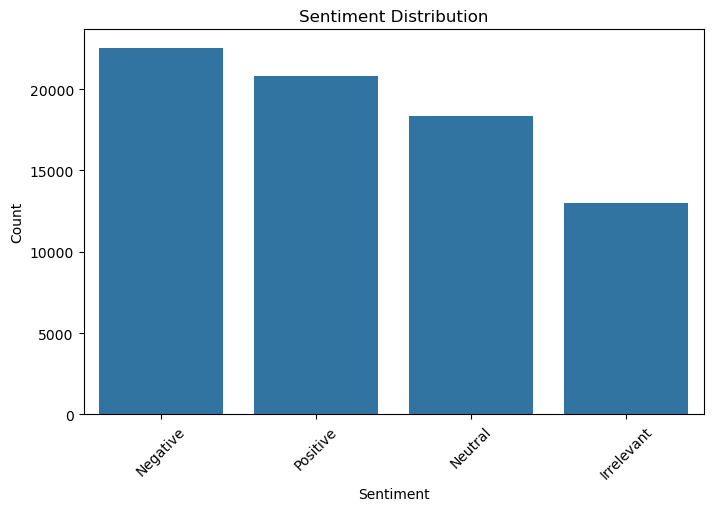

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

## **Observation**

### The dataset contains multiple sentiment classes. The count plot shows whether the dataset is balanced or imbalanced. A balanced dataset generally helps machine learning models learn each class more effectively.

## 5. Data Cleaning

### The dataset is cleaned by removing missing text values and duplicate records. This ensures that the machine learning models are trained on high-quality and unique text data.

In [45]:
print("Original Shape :", df.shape)

df = df.dropna(subset=["Text"])

df = df.drop_duplicates()

print("New Shape :", df.shape)

Original Shape : (74682, 4)
New Shape : (71656, 4)


In [46]:
df.isnull().sum()

Tweet_ID     0
Entity       0
Sentiment    0
Text         0
dtype: int64

### **Observation**

### Rows with missing tweet text were removed because text is essential for sentiment analysis. Duplicate records were also removed to avoid bias during model training.

## 6. Text Preprocessing

### Before training machine learning models, the text is cleaned and standardized.

The preprocessing steps include:
- Convert text to lowercase
- Remove punctuation
- Remove numbers
- Remove stopwords
- Tokenization
- Lemmatization

These steps help reduce noise and improve model performance.

In [51]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nikky\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [55]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [56]:
def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [57]:
df["Clean_Text"] = df["Text"].apply(preprocess_text)

df[["Text","Clean_Text"]].head()

,Text,Clean_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


## 7. TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical feature vectors.

It gives higher importance to words that appear frequently in one document but not across all documents. This helps machine learning algorithms understand which words are more informative for predicting sentiment.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"])

y = df["Sentiment"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (71656, 5000)


## 8. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

The training set is used to train the model, while the testing set evaluates its performance on unseen data.

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (57324, 5000)
Testing Samples : (14332, 5000)


### **Observation**

### The dataset has been successfully converted into numerical TF-IDF features and split into training (80%) and testing (20%) sets. The data is now ready for machine learning model training.

## 9. Naive Bayes Classifier

Naive Bayes is a simple and efficient probabilistic machine learning algorithm commonly used for text classification tasks such as sentiment analysis. It performs well with TF-IDF features and serves as a strong baseline model.

In [61]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.6371057772816076

Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.74      0.36      0.48      2529
    Negative       0.63      0.81      0.71      4383
     Neutral       0.67      0.53      0.59      3543
    Positive       0.60      0.73      0.66      3877

    accuracy                           0.64     14332
   macro avg       0.66      0.60      0.61     14332
weighted avg       0.65      0.64      0.63     14332



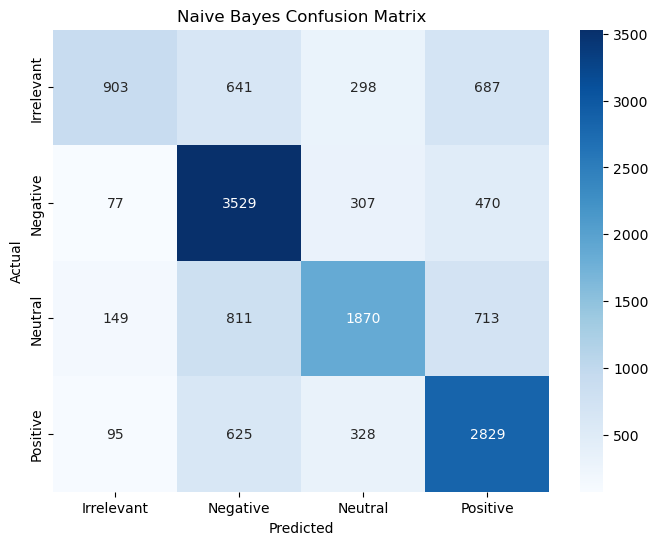

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

### **Observation**

### The Naive Bayes classifier was trained successfully and evaluated using the testing dataset. The confusion matrix shows the number of correctly and incorrectly classified samples for each sentiment class.

## 10. Logistic Regression Classifier

Logistic Regression is a supervised machine learning algorithm widely used for text classification. It often performs better than Naive Bayes on TF-IDF features because it learns the relationship between features and sentiment classes more effectively.

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6841334077588613

Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.68      0.52      0.59      2529
    Negative       0.74      0.78      0.76      4383
     Neutral       0.63      0.65      0.64      3543
    Positive       0.67      0.71      0.69      3877

    accuracy                           0.68     14332
   macro avg       0.68      0.67      0.67     14332
weighted avg       0.68      0.68      0.68     14332



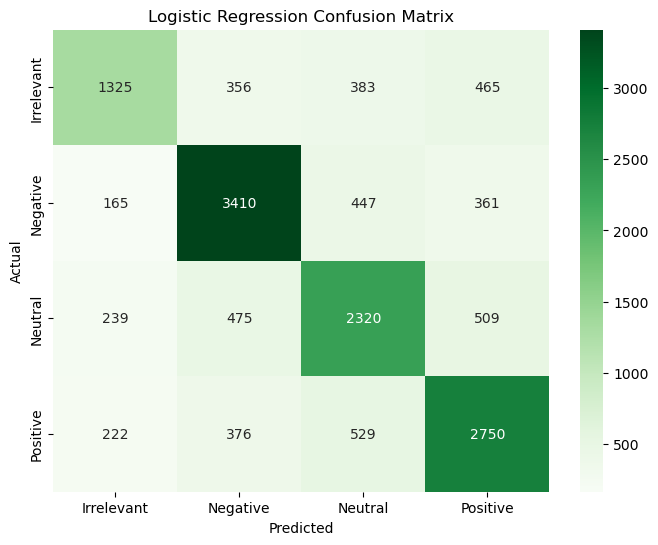

In [64]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## 11. Model Comparison

The performance of Naive Bayes and Logistic Regression models is compared using accuracy scores to determine which classifier performs better for sentiment prediction.

In [66]:
comparison = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred)
}

comparison

{'Naive Bayes': 0.6371057772816076, 'Logistic Regression': 0.6841334077588613}

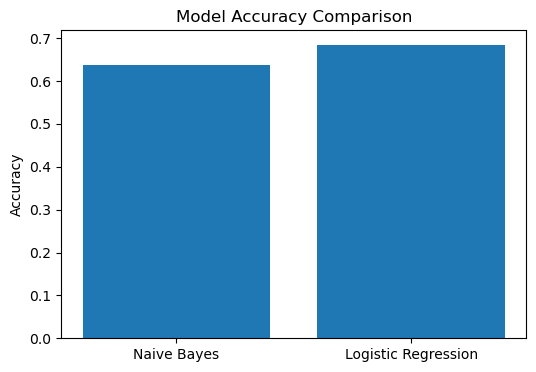

In [67]:
plt.figure(figsize=(6,4))

plt.bar(comparison.keys(), comparison.values())

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

## 12. WordCloud Visualization

Word clouds are generated for each sentiment class to highlight the most frequently occurring words. This helps understand the common terms associated with Positive, Negative, and Neutral sentiments.

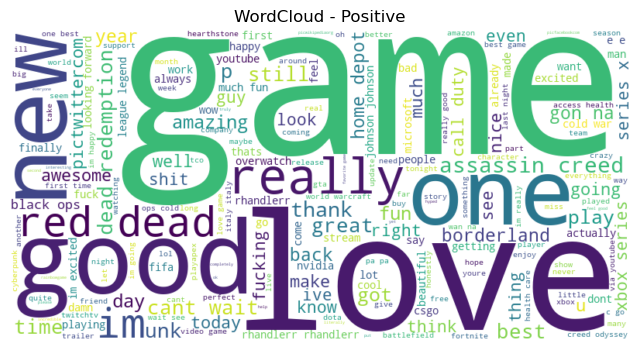

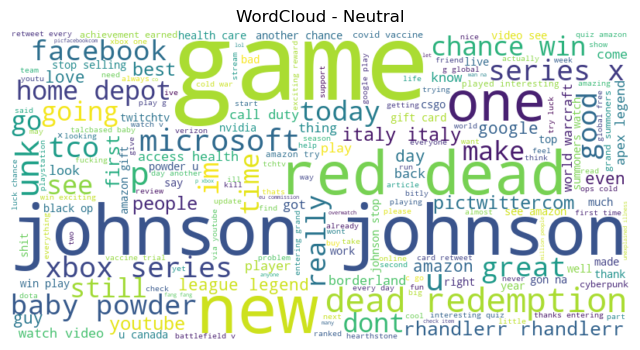

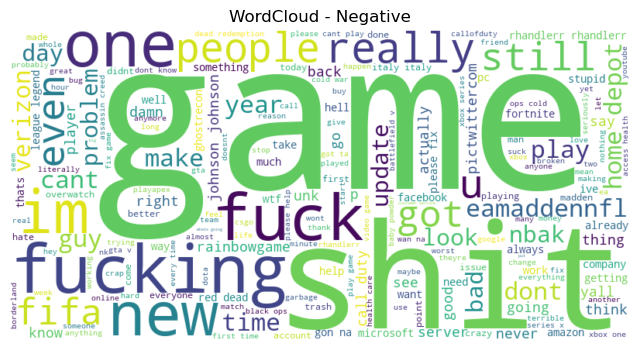

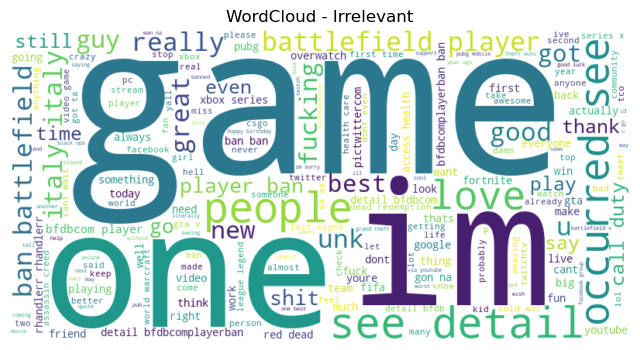

In [68]:
from wordcloud import WordCloud

sentiments = df["Sentiment"].unique()

for sentiment in sentiments:
    text = " ".join(df[df["Sentiment"] == sentiment]["Clean_Text"].astype(str))

    plt.figure(figsize=(8,5))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {sentiment}")

    plt.show()

## 13. Error Analysis

This section displays five examples that were misclassified by the best-performing model. Analysing these examples helps identify limitations of the model and areas for future improvement.

In [69]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

misclassified = results[results["Actual"] != results["Predicted"]]

misclassified.head(5)

,Actual,Predicted
1,Neutral,Negative
2,Positive,Negative
3,Irrelevant,Neutral
5,Negative,Neutral
8,Neutral,Negative


## 14. Conclusion

Two machine learning models, Naive Bayes and Logistic Regression, were trained and evaluated for sentiment classification.

The text was preprocessed using lowercase conversion, punctuation removal, stopword removal, tokenization, and lemmatization. TF-IDF Vectorization was used to convert text into numerical features.

Based on the evaluation metrics, the model with the higher accuracy performed better for sentiment prediction.

### Real-World Applications

- Customer review analysis
- Brand reputation monitoring
- Social media sentiment analysis
- Product feedback analysis
- Public opinion analysis